### Build feature table

This is the true dataset that will be used for the analysis.

| participant_id | age | condition  | alpha_power_8_12 | fooof_alpha_cf | fooof_alpha_pw | fooof_alpha_bw | n_epochs_kept | fooof_r2 | fooof_error |
| -------------- | --: | ---------- | ---------------: | -------------: | -------------: | -------------: | ------------: | -------: | ----------: |
| sub-001        |  24 | EyesClosed |             1.82 |           10.4 |           0.61 |            2.3 |            85 |     0.97 |        0.03 |
| sub-001        |  24 | EyesOpen   |             0.95 |           10.1 |           0.22 |            2.0 |            82 |     0.95 |        0.05 |


#### Imports and paths

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from fooof import FOOOF
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
RAW_ROOT = PROJECT_ROOT / "data" / "ds005385"
PROCESSED_ROOT = PROJECT_ROOT / "data_processed"

manifest_file = PROCESSED_ROOT / "manifest_pre_ses1.csv"
out_file = PROCESSED_ROOT / "features_pre_ses1.csv"

manifest = pd.read_csv(manifest_file)
manifest.head()

,participant_id,age,eyes_closed_file,eyes_open_file
0,sub-001,60,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
1,sub-002,67,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
2,sub-003,44,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
3,sub-004,24,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
4,sub-005,48,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...


#### Define constants

In [5]:
OCCIPITAL_CHANNELS = ["O1", "Oz", "O2"]
ALPHA_BAND = (8.0, 12.0)

RESAMPLE_FREQ = 250
FILTER_LO = 1.0
FILTER_HI = 40.0
NOTCH_FREQ = 50.0

EPOCH_LENGTH = 2.0
PTP_REJECT_VOLTS = 150e-6   # 150 microvolts
MIN_EPOCHS_REQUIRED = 10

#### Helper functions

In [6]:
def find_matching_channels_tsv(edf_path: str):
    edf_path = Path(edf_path)
    return edf_path.with_name(edf_path.name.replace("_eeg.edf", "_channels.tsv"))


def read_bad_channels(channels_tsv):
    channels_tsv = Path(channels_tsv)
    if not channels_tsv.exists():
        return []
    
    ch_df = pd.read_csv(channels_tsv, sep="\t")
    
    if "name" not in ch_df.columns or "status" not in ch_df.columns:
        return []
    
    bads = ch_df.loc[
        ch_df["status"].astype(str).str.lower() == "bad", "name"
    ].tolist()
    
    return bads


def preprocess_raw(edf_path: str):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    raw.pick("eeg")
    
    # mark bad channels if available
    channels_tsv = find_matching_channels_tsv(edf_path)
    raw.info["bads"] = read_bad_channels(channels_tsv)
    
    # standard first-pass preprocessing
    raw.resample(RESAMPLE_FREQ, npad="auto")
    raw.filter(FILTER_LO, FILTER_HI, verbose="ERROR")
    raw.notch_filter(freqs=[NOTCH_FREQ], verbose="ERROR")
    raw.set_eeg_reference("average", verbose="ERROR")
    
    # keep occipital ROI if present
    keep = [ch for ch in OCCIPITAL_CHANNELS if ch in raw.ch_names]
    if len(keep) == 0:
        raise ValueError(f"No occipital channels found in {edf_path}")
    
    raw.pick(keep)
    return raw


def make_clean_epochs(raw):
    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=EPOCH_LENGTH,
        overlap=0.0,
        preload=True,
        verbose="ERROR"
    )
    
    data = epochs.get_data(copy=False)  # shape: epochs, channels, time
    ptp = np.ptp(data, axis=-1).max(axis=1)  # max peak-to-peak across channels
    keep_mask = ptp < PTP_REJECT_VOLTS
    
    epochs_clean = epochs[keep_mask]
    return epochs_clean


def compute_mean_psd(epochs):
    spec = epochs.compute_psd(
        method="welch",
        fmin=2.0,
        fmax=30.0,
        verbose="ERROR"
    )
    psds, freqs = spec.get_data(return_freqs=True)  # epochs, channels, freqs
    psd_mean = psds.mean(axis=(0, 1))               # average across epochs & channels
    return freqs, psd_mean


def compute_alpha_bandpower(freqs, psd, band=(8.0, 12.0)):
    mask = (freqs >= band[0]) & (freqs <= band[1])
    if mask.sum() == 0:
        return np.nan
    bp = np.trapz(psd[mask], freqs[mask])
    if bp <= 0:
        return np.nan
    return np.log10(bp)


def run_fooof(freqs, psd):
    fm = FOOOF(
        peak_width_limits=[1, 8],
        max_n_peaks=6,
        min_peak_height=0.05,
        peak_threshold=2.0,
        aperiodic_mode="fixed",
        verbose=False,
    )
    
    fm.fit(freqs, psd, [2, 30])
    
    peaks = fm.peak_params_
    if peaks is None or len(peaks) == 0:
        return np.nan, np.nan, np.nan, fm.r_squared_, fm.error_
    
    # keep peaks in an alpha-ish range
    alpha_peaks = peaks[(peaks[:, 0] >= 7.0) & (peaks[:, 0] <= 13.0)]
    
    if len(alpha_peaks) == 0:
        return np.nan, np.nan, np.nan, fm.r_squared_, fm.error_
    
    # choose strongest alpha peak
    best = alpha_peaks[np.argmax(alpha_peaks[:, 1])]
    cf, pw, bw = best
    
    return cf, pw, bw, fm.r_squared_, fm.error_

#### Extract features for one recording

In [7]:
def extract_features_for_recording(edf_path, participant_id, age, condition):
    try:
        raw = preprocess_raw(edf_path)
        epochs = make_clean_epochs(raw)
        n_epochs_kept = len(epochs)
        
        if n_epochs_kept < MIN_EPOCHS_REQUIRED:
            return {
                "participant_id": participant_id,
                "age": age,
                "condition": condition,
                "alpha_power_8_12": np.nan,
                "fooof_alpha_cf": np.nan,
                "fooof_alpha_pw": np.nan,
                "fooof_alpha_bw": np.nan,
                "n_epochs_kept": n_epochs_kept,
                "fooof_r2": np.nan,
                "fooof_error": np.nan,
            }
        
        freqs, psd = compute_mean_psd(epochs)
        alpha_power = compute_alpha_bandpower(freqs, psd, ALPHA_BAND)
        cf, pw, bw, r2, err = run_fooof(freqs, psd)
        
        return {
            "participant_id": participant_id,
            "age": age,
            "condition": condition,
            "alpha_power_8_12": alpha_power,
            "fooof_alpha_cf": cf,
            "fooof_alpha_pw": pw,
            "fooof_alpha_bw": bw,
            "n_epochs_kept": n_epochs_kept,
            "fooof_r2": r2,
            "fooof_error": err,
        }
    
    except Exception as e:
        return {
            "participant_id": participant_id,
            "age": age,
            "condition": condition,
            "alpha_power_8_12": np.nan,
            "fooof_alpha_cf": np.nan,
            "fooof_alpha_pw": np.nan,
            "fooof_alpha_bw": np.nan,
            "n_epochs_kept": np.nan,
            "fooof_r2": np.nan,
            "fooof_error": np.nan,
            "error": str(e),
        }

#### Build features table

In [9]:
import time

checkpoint_file = PROCESSED_ROOT / "features_pre_ses1_checkpoint.csv"

# If a checkpoint already exists, load it and skip completed participants
if checkpoint_file.exists():
    features_existing = pd.read_csv(checkpoint_file)
    completed_ids = set(features_existing["participant_id"].unique())
    print(f"Found checkpoint with {len(features_existing)} rows")
    print(f"Completed participants: {len(completed_ids)}")
else:
    features_existing = pd.DataFrame()
    completed_ids = set()
    print("No checkpoint found, starting fresh")

rows = []

# Keep only participants not already processed
manifest_todo = manifest[~manifest["participant_id"].isin(completed_ids)].copy()
manifest_todo = manifest_todo.reset_index(drop=True)

print(f"Participants remaining: {len(manifest_todo)}")

start_all = time.time()

for i, (_, row) in enumerate(manifest_todo.iterrows(), start=1):
    participant_id = row["participant_id"]
    age = row["age"] if "age" in row else np.nan

    ec_file = row["eyes_closed_file"]
    eo_file = row["eyes_open_file"]

    start_one = time.time()
    print(f"[{i}/{len(manifest_todo)}] Processing {participant_id} ...")

    ec_features = extract_features_for_recording(
        ec_file, participant_id, age, "EyesClosed"
    )
    eo_features = extract_features_for_recording(
        eo_file, participant_id, age, "EyesOpen"
    )

    rows.extend([ec_features, eo_features])

    # Save checkpoint after every participant
    features_new = pd.DataFrame(rows)
    features_combined = pd.concat([features_existing, features_new], ignore_index=True)
    features_combined.to_csv(checkpoint_file, index=False)

    elapsed_one = time.time() - start_one
    print(f"    done in {elapsed_one:.1f} s")

elapsed_all = time.time() - start_all
print(f"Finished remaining participants in {elapsed_all/60:.1f} min")

# Final combined table
if checkpoint_file.exists():
    features = pd.read_csv(checkpoint_file)
else:
    features = pd.DataFrame(rows)

features = features.sort_values(["participant_id", "condition"]).reset_index(drop=True)
features.head()

No checkpoint found, starting fresh
Participants remaining: 608
[1/608] Processing sub-001 ...
    done in 2.5 s
[2/608] Processing sub-002 ...
    done in 2.2 s
[3/608] Processing sub-003 ...
    done in 2.0 s
[4/608] Processing sub-004 ...
    done in 2.3 s
[5/608] Processing sub-005 ...
    done in 1.9 s
[6/608] Processing sub-006 ...
    done in 1.9 s
[7/608] Processing sub-007 ...
    done in 2.0 s
[8/608] Processing sub-008 ...
    done in 1.8 s
[9/608] Processing sub-009 ...
    done in 2.0 s
[10/608] Processing sub-010 ...
    done in 2.0 s
[11/608] Processing sub-011 ...
    done in 1.8 s
[12/608] Processing sub-012 ...
    done in 1.9 s
[13/608] Processing sub-013 ...
    done in 2.0 s
[14/608] Processing sub-014 ...
    done in 1.9 s
[15/608] Processing sub-015 ...
    done in 2.2 s
[16/608] Processing sub-016 ...
    done in 2.2 s
[17/608] Processing sub-017 ...
    done in 2.0 s
[18/608] Processing sub-018 ...
    done in 1.9 s
[19/608] Processing sub-019 ...
    done in 2

,participant_id,age,condition,alpha_power_8_12,fooof_alpha_cf,fooof_alpha_pw,fooof_alpha_bw,n_epochs_kept,fooof_r2,fooof_error
0,sub-001,60,EyesClosed,-10.268460,10.124218,1.674327,1.942220,91,0.958835,0.087013
1,sub-001,60,EyesOpen,-11.278344,11.232861,0.293344,3.081986,91,0.984296,0.041236
2,sub-002,67,EyesClosed,-10.221186,9.256943,1.711060,2.451334,91,0.964858,0.078536
3,sub-002,67,EyesOpen,-11.416633,8.463996,0.211487,1.000000,91,0.981021,0.053521
4,sub-003,44,EyesClosed,-10.992970,11.359863,1.384598,1.743643,108,0.967652,0.067379


#### Inspect and save

In [12]:
print(features.shape)
print(features.isna().sum())
print(features.head(10))
features.to_csv(out_file, index=False)
print(f"Saved features to: {out_file}")

(1216, 10)
participant_id        0
age                   0
condition             0
alpha_power_8_12      1
fooof_alpha_cf      124
fooof_alpha_pw      124
fooof_alpha_bw      124
n_epochs_kept         0
fooof_r2              1
fooof_error           1
dtype: int64
  participant_id  age   condition  alpha_power_8_12  fooof_alpha_cf  \
0        sub-001   60  EyesClosed        -10.268460       10.124218   
1        sub-001   60    EyesOpen        -11.278344       11.232861   
2        sub-002   67  EyesClosed        -10.221186        9.256943   
3        sub-002   67    EyesOpen        -11.416633        8.463996   
4        sub-003   44  EyesClosed        -10.992970       11.359863   
5        sub-003   44    EyesOpen        -11.751098             NaN   
6        sub-004   24  EyesClosed         -9.989071       10.371027   
7        sub-004   24    EyesOpen        -11.383964             NaN   
8        sub-005   48  EyesClosed        -10.728284       10.190261   
9        sub-005   48    E

#### Dataset Validation

##### Check that EO and EC counts are balanced

In [13]:
features["condition"].value_counts()

condition
EyesClosed    608
EyesOpen      608
Name: count, dtype: int64

##### Check whether EC alpha is generally higher than EO alpha

In [14]:
features.groupby("condition")["alpha_power_8_12"].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
EyesClosed,608.0,-10.732749,0.591028,-12.071398,-11.166606,-10.676601,-10.270795,-9.481100
EyesOpen,607.0,-11.326337,0.380787,-12.124222,-11.606699,-11.388649,-11.117909,-10.105848


##### Check whether the EO/EC effect is present in our sample

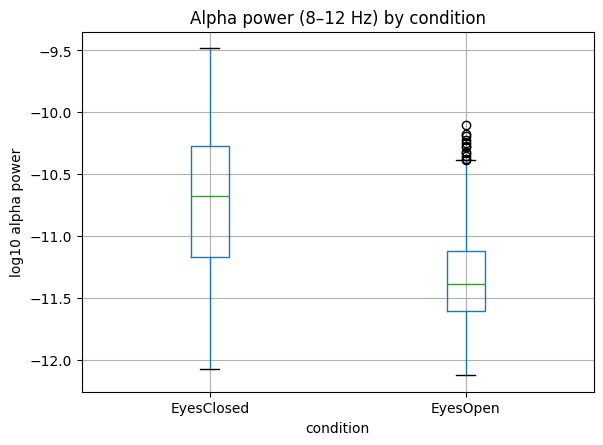

In [ ]:
import matplotlib.pyplot as plt

features.boxplot(column="alpha_power_8_12", by="condition")
plt.title("Alpha power (8–12 Hz) by condition")
plt.suptitle("")
plt.ylabel("log10 alpha power")
plt.show()